In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

# Bootstrap

- **amostragem aleatória com reposição**
- técnica de reamostragem para simular a seleção de novas amostras (quando repetir experimentos não é viável ou possível)
- tipicamente, a nova amostra tem tamanho *n*, onde *n* é o tamanho do conjunto de dados original

## Mediana amostral, desvio padrão e estimação da mediana populacional

Vamos usar o dataset Iris. Este conjunto de dados consiste em 3 diferentes tipos de flores íris (Setosa, Versicolour e Virginica), com comprimentos de pétala e sépala armazenados em um numpy.ndarray de 150x4.

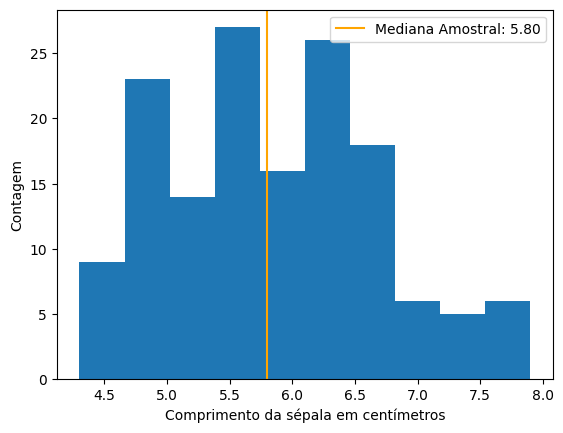

In [2]:
df = pd.read_csv('iris.csv')

x = df['sepal.length'].values
x_median = np.median(x)
plt.hist(x, bins=10)
plt.axvline(x_median, color='orange', label='Mediana Amostral: %.2f' % x_median)
plt.xlabel('Comprimento da sépala em centímetros')
plt.ylabel('Contagem')
plt.legend(loc=1)
plt.show()

## Estimação da mediana

In [8]:
def bootstrap_median(x, n_bootstrap_samples, seed=123):

    rng = np.random.RandomState(seed)
    sample_medians = np.zeros(shape=n_bootstrap_samples)
    
    for i in range(n_bootstrap_samples):
        boot_sample = rng.choice(x, size=x.shape[0], replace=True)
        bootstrap_replicate = np.median(boot_sample)
        sample_medians[i] = bootstrap_replicate
    return sample_medians

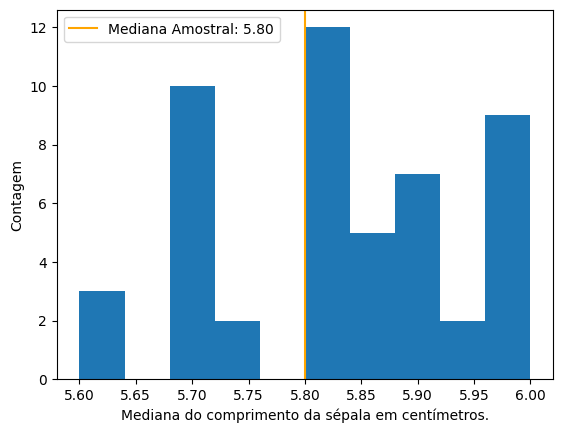

In [4]:
boot_50 = bootstrap_median(x, n_bootstrap_samples=50, seed=123)

boot_median = np.median(boot_50)
plt.hist(boot_50, bins=10)
plt.axvline(boot_median, color='orange', label='Mediana Amostral: %.2f' % boot_median)
plt.xlabel('Mediana do comprimento da sépala em centímetros.')
plt.ylabel('Contagem')
plt.legend(loc=2)
plt.show()

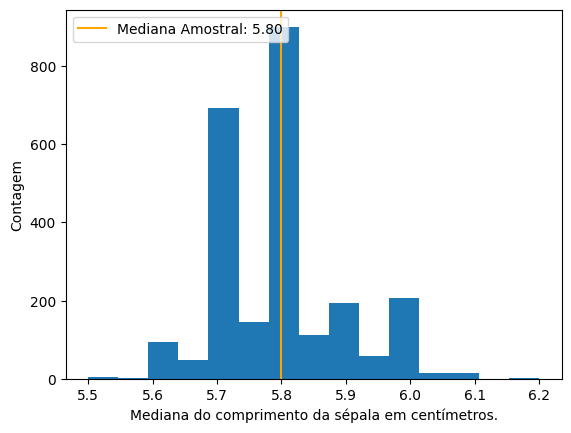

In [11]:
boot_2500 = bootstrap_median(x, n_bootstrap_samples=2500, seed=123)

boot_mean = np.median(boot_2500)
plt.hist(boot_2500, bins=15)
plt.axvline(boot_median, color='orange', label='Mediana Amostral: %.2f' % boot_median)
plt.xlabel('Mediana do comprimento da sépala em centímetros.')
plt.ylabel('Contagem')
plt.legend(loc=2)
plt.show()

Agora conserguimos calcular o desvio padrão do estimador da mediana:

In [6]:
median_std = np.std(boot_2500, ddof=1)
median_std

0.10454574082558267

## Intervalos de Confiança

Agora vamos calcular um intervalo de confiança de 95% para a mediana.

In [16]:
boot_2500 = bootstrap_median(x, n_bootstrap_samples=2500, seed=123)

lower, upper = np.percentile(boot_2500, [2.5, 97.5])

print('Intervalo de confiança de 95%%: [%.2f, %.2f]' % (lower, upper))

Intervalo de confiança de 95%: [5.60, 6.00]
